In [2]:
pip install matplotlib



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
iimport numpy as np
import matplotlib.pyplot as plt

# Global settings for visual clarity
%matplotlib inline 
np.random.seed(42) # Ensures the "Robertson Noise" is consistent every time you run it


In [45]:
# 1. Define the Muscle Pool
n_units = 100 # Small pool to make individual "jags" recognizable
RR = 30      # Recruitment Range (Henneman's Size Principle)
FR = 100     # Force Range (Max Force of the largest unit vs smallest)

# Exponential distribution based on the Fuglevand Model
thresholds = np.exp(np.log(RR) * np.linspace(0, 1, n_units))
max_forces = np.exp(np.log(FR) * np.linspace(0, 1, n_units))

print("Motor Unit Thresholds:", thresholds)
print("Motor Unit Max Forces:", max_forces)

Motor Unit Thresholds: [ 1.          1.0349525   1.07112667  1.10856522  1.14731235  1.18741378
  1.22891685  1.27187057  1.31632562  1.36233449  1.40995148  1.4592328
  1.51023663  1.56302317  1.61765474  1.67419581  1.73271313  1.79327578
  1.85595525  1.92082552  1.98796317  2.05744745  2.12936037  2.20378684
  2.28081469  2.36053486  2.44304144  2.52843184  2.61680685  2.70827078
  2.80293161  2.90090107  3.00229481  3.10723251  3.21583804  3.32823961
  3.4445699   3.56496622  3.68957069  3.81853039  3.95199757  4.09012975
  4.23309     4.38104706  4.5341756   4.69265636  4.85667642  5.02642938
  5.20211564  5.38394257  5.57212481  5.76688449  5.9684515   6.17706378
  6.39296759  6.61641777  6.84767809  7.08702154  7.33473064  7.59109779
  7.85642561  8.13102731  8.41522701  8.70936021  9.0137741   9.32882801
  9.65489385  9.99235649 10.34161431 10.70307955 11.07717891 11.46435397
 11.86506177 12.2797753  12.70898411 13.15319484 13.61293185 14.08873781
 14.58117438 15.09082283 15.6

In [47]:

dt = 0.01  # 10ms time steps
time = np.arange(0, 10, dt)
# A sine wave representing a 10-second rhythmic contraction
neural_drive = 20 * np.sin(time * 0.6) + 20



In [46]:
# Model A: Static (No ODE)
force_static = []
for drive in neural_drive:
    # Instant sigmoid activation based on Fuglevand logic
    target = 1 / (1 + np.exp(-10 * (drive - thresholds)))
    force_static.append(np.sum(max_forces * target))

# Model B: Dynamic (Liu et al. ODE via Euler Method)
force_ode = []
current_a = np.zeros(n_units)
tau = 0.15 # The time constant for activation lag

for drive in neural_drive:
    target = 1 / (1 + np.exp(-10 * (drive - thresholds)))
    # ODE: da/dt = (target - current) / tau
    da_dt = (target - current_a) / tau
    current_a += da_dt * dt # The Euler Step
    force_ode.append(np.sum(max_forces * current_a))



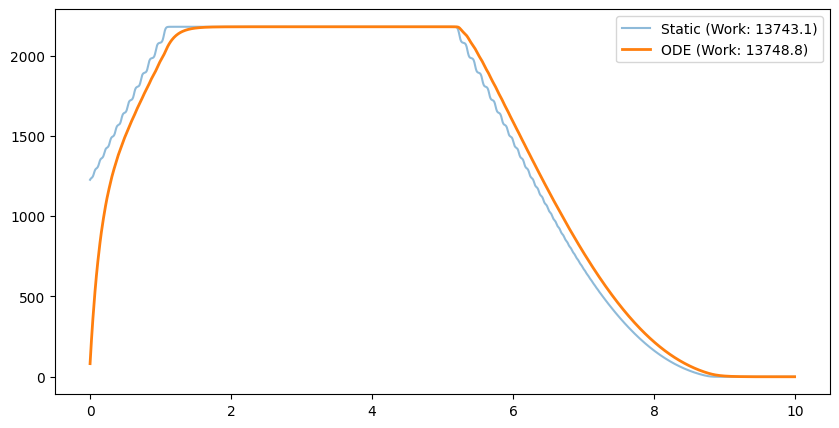

In [48]:
# Numerical Integration using the Trapezoidal Rule
work_static = np.trapezoid(force_static, dx=dt)
work_ode = np.trapezoid(force_ode, dx=dt)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(time, force_static, label=f"Static (Work: {work_static:.1f})", alpha=0.5)
plt.plot(time, force_ode, label=f"ODE (Work: {work_ode:.1f})", linewidth=2)
plt.legend()
plt.show()



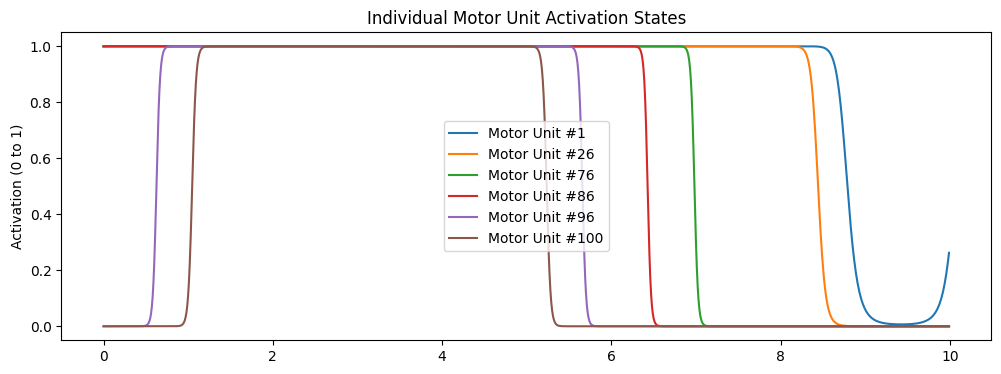

In [40]:
plt.figure(figsize=(12, 4))

# Choose a few units to track (e.g., the 1st, 5th, and 10th units)
units_to_track = [0, 25, 75, 85, 95, 99] 

for i in units_to_track:
    unit_target = [sigmoid_activation(d, thresholds[i]) for d in neural_drive]
    plt.plot(time, unit_target, label=f"Motor Unit #{i+1}")

plt.title("Individual Motor Unit Activation States")
plt.ylabel("Activation (0 to 1)")
plt.legend()
plt.show()

